# NB12 — Nivel 1: Entrenamiento del prior poblacional con naiveAutoML

**Objetivo**: entrenar el Nivel 1 del modelo jerárquico de RUNA usando **naiveautoml** (github.com/fmohr/naiveautoml) sobre el dataset limpio de Endomondo producido por NB11.

**Contexto metodológico (tesis)**:
- Fuente: FitRec / Endomondo (Ni, Muhlstein & McAuley, WWW 2019) — uso académico.
- Task: regresión — target `pace_min_km`, features (demografía + FCmax observada + zona FC + velocidad media).
- Protocolo: **Leave-One-User-Out CV** (LOUO-CV) + comparación con baselines Karvonen/VDOT.
- AutoML: naiveautoml explora Ridge, Lasso, RF, GB, XGB, LGBM, MLP + su hiperparámetros.
- Intervalos: split-conformal prediction (α=0.2 → 80% cobertura nominal).
- Comparación estadística: Friedman–Nemenyi entre top-5 modelos.

**Producto final**: artefacto `nivel1_prior_poblacional.pkl` que se usará como prior en NB13 (Nivel 2 generalizable con RUNA/Strava).

## 0 · Setup y dependencias

Instalación (correr la primera vez):
```bash
pip install naiveautoml scikit-learn pandas numpy scipy matplotlib seaborn
# opcional, para comparación con boosted trees
pip install xgboost lightgbm
```

In [1]:
import os, sys, json, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

BASE = Path(r'C:/Users/RentAdvisor/OneDrive/Documentos/Maestría Analítica Aplicada/running_coaching')
IN_PARQUET = BASE / 'ml' / 'notebooks' / 'outputs' / 'nb11' / 'endomondo_runs_clean_sample.parquet'
OUT_DIR = BASE / 'ml' / 'notebooks' / 'outputs' / 'nb12'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Input:', IN_PARQUET, '|', 'exists:', IN_PARQUET.exists())

Input: C:\Users\RentAdvisor\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb11\endomondo_runs_clean_sample.parquet | exists: True


In [2]:
df = pd.read_parquet(IN_PARQUET)
print(f'Shape: {df.shape}')
print(f'Usuarios únicos: {df["userId"].nunique()}')
print(df.head().to_string())
print()
print(df.describe().round(3).to_string())

Shape: (482, 13)
Usuarios únicos: 23
          id  userId  gender     hr_mean  hr_max  hr_median  fcmax_obs  pct_fcmax zona  speed_mean  pace_min_km  n_points_hr  duration_s
0  369872690  279317  female  145.140281     158      147.0        177  82.000159   Z4   11.712408     5.122772          499        3312
1  369995230  279317  female  136.106212     152      136.0        177  76.896165   Z3   11.313473     5.303411          499        3364
2  361558746  279317  female  147.553106     177      148.0        177  83.363337   Z4   11.909880     5.037834          499        4765
3  360051904  279317  female  161.040080     176      166.0        177  90.983096   Z5   12.552738     4.779834          499        3217
4  357328684  279317  female  155.739479     162      156.0        177  87.988406   Z4   11.854161     5.061514          499        2723

                 id        userId  hr_mean   hr_max  hr_median  fcmax_obs  pct_fcmax  speed_mean  pace_min_km  n_points_hr  duration_s
count

## 1 · Preparación de features y target

**Features candidatos**:
- `gender` (categórico → binario)
- `fcmax_obs` (proxy de FCmax sin edad)
- `hr_mean` (FC media de la sesión)
- `pct_fcmax` (% de FCmax, proxy de intensidad)
- `zona` (categórico Z1-Z5)
- `speed_mean` (solo como validación cruzada del target; no se usa como feature porque es ~ el target)

**Target**: `pace_min_km` (ritmo medio de la sesión)

**Grupos para LOUO-CV**: `userId`

In [3]:
# Limpieza final: filtro running-coherente
df = df.dropna(subset=['pace_min_km','hr_mean','fcmax_obs','gender','zona']).copy()
df = df[(df['pace_min_km'].between(3.0, 12.0)) & (df['hr_mean'].between(80, 210)) & (df['fcmax_obs'].between(130, 220))]

# Encoding simple
df['gender_bin'] = (df['gender'].astype(str).str.lower().str.startswith('m')).astype(int)
zona_map = {'Z1':1, 'Z2':2, 'Z3':3, 'Z4':4, 'Z5':5}
df['zona_num'] = df['zona'].map(zona_map)

FEATURES = ['gender_bin', 'fcmax_obs', 'hr_mean', 'pct_fcmax', 'zona_num']
TARGET = 'pace_min_km'
GROUP = 'userId'

X = df[FEATURES].values
y = df[TARGET].values
groups = df[GROUP].values
print(f'X: {X.shape} | y: {y.shape} | grupos: {len(np.unique(groups))}')
print(f'Target (ritmo min/km): mean={y.mean():.2f}, std={y.std():.2f}, p10={np.percentile(y,10):.2f}, p90={np.percentile(y,90):.2f}')

X: (482, 5) | y: (482,) | grupos: 23
Target (ritmo min/km): mean=5.60, std=1.13, p10=4.53, p90=7.18


## 2 · Baselines tradicionales

Antes de correr AutoML, fijamos los baselines del deporte para tener referencia de comparación.

In [4]:
def baseline_mean_pace(X, y, groups):
    """Predice siempre la mediana de ritmo del training set (naive)."""
    logo = LeaveOneGroupOut()
    preds = np.zeros_like(y, dtype=float)
    for tr, te in logo.split(X, y, groups):
        preds[te] = np.median(y[tr])
    return preds

def baseline_karvonen(X, y, groups, feature_names=FEATURES):
    """Estimación lineal: pace = a + b * pct_fcmax (regresión por zona FC).
    Sirve como proxy de la curva Karvonen clásica (FC→intensidad→ritmo)."""
    from sklearn.linear_model import LinearRegression
    idx_pct = feature_names.index('pct_fcmax')
    logo = LeaveOneGroupOut()
    preds = np.zeros_like(y, dtype=float)
    for tr, te in logo.split(X, y, groups):
        # Nota: X[tr][:, [idx]] garantiza 2D (N,1). X[tr, [idx]] hace fancy
        # indexing broadcast y retorna 1D, que sklearn rechaza.
        m = LinearRegression().fit(X[tr][:, [idx_pct]], y[tr])
        preds[te] = m.predict(X[te][:, [idx_pct]])
    return preds

# Ejecutar baselines
print('Ejecutando baselines (LOUO-CV)...')
p_naive    = baseline_mean_pace(X, y, groups)
p_karvonen = baseline_karvonen(X, y, groups)

def metricas(nombre, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'modelo': nombre, 'MAE_min_km': mae, 'MAE_sec_km': mae*60, 'RMSE_min_km': rmse, 'R2': r2}

base_results = [metricas('Baseline naive (mediana)', y, p_naive),
                metricas('Baseline Karvonen-like', y, p_karvonen)]
pd.DataFrame(base_results).round(3)

Ejecutando baselines (LOUO-CV)...


,modelo,MAE_min_km,MAE_sec_km,RMSE_min_km,R2
0,Baseline naive (mediana),1.051,63.031,1.329,-0.391
1,Baseline Karvonen-like,0.936,56.178,1.176,-0.088


## 3 · naiveautoml — búsqueda automatizada

Según documentación: https://github.com/fmohr/naiveautoml

```python
from naiveautoml import NaiveAutoML
naml = NaiveAutoML(task_type='regression', timeout_overall=600, timeout_candidate=60)
naml.fit(X_train, y_train)
```

**Configuración para la tesis**:
- `timeout_overall = 1800` (30 min por fold)
- `timeout_candidate = 90` (90 s por modelo candidato)
- Métrica: `neg_mean_absolute_error`
- Loop externo: LOUO-CV (por usuario)

Para no hacer una corrida masiva innecesaria, primero evaluamos en un **subset estratificado de 30 usuarios** para prototipado. La corrida completa sobre todos los usuarios va en `12b_run_full.py`.

In [5]:
# Submuestra estratificada de 30 usuarios con >=10 sesiones
user_counts = df.groupby('userId').size()
eligible_users = user_counts[user_counts >= 10].index.tolist()
print(f'Usuarios elegibles (>=10 sesiones): {len(eligible_users)}')

rng = np.random.default_rng(42)
sample_users = rng.choice(eligible_users, size=min(30, len(eligible_users)), replace=False)
df_sub = df[df['userId'].isin(sample_users)].copy()
X_sub = df_sub[FEATURES].values
y_sub = df_sub[TARGET].values
g_sub = df_sub[GROUP].values
print(f'Subset: {X_sub.shape[0]} sesiones, {len(sample_users)} usuarios')

Usuarios elegibles (>=10 sesiones): 10
Subset: 454 sesiones, 10 usuarios


In [6]:
# Fallback si naiveautoml no está instalado: comparación manual de modelos
USE_NAIVEAUTOML = False
try:
    from naiveautoml import NaiveAutoML
    USE_NAIVEAUTOML = True
    print('naiveautoml detectado')
except ImportError:
    print('naiveautoml NO instalado → usando comparación manual como plan B')
    print('Para instalar: pip install naiveautoml')

naiveautoml NO instalado → usando comparación manual como plan B
Para instalar: pip install naiveautoml


In [7]:
# Comparación manual — modelos candidatos que naiveautoml exploraría
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

candidates = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0),
    'MLP': MLPRegressor(hidden_layer_sizes=(32,16), max_iter=500, random_state=0),
}

try:
    import xgboost as xgb
    candidates['XGBoost'] = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=0)
except ImportError: pass
try:
    import lightgbm as lgb
    candidates['LightGBM'] = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=0, verbose=-1)
except ImportError: pass

def eval_model_louo(model, X, y, groups):
    logo = LeaveOneGroupOut()
    preds = np.zeros_like(y, dtype=float)
    for tr, te in logo.split(X, y, groups):
        scaler = StandardScaler().fit(X[tr])
        m = model.__class__(**model.get_params())
        m.fit(scaler.transform(X[tr]), y[tr])
        preds[te] = m.predict(scaler.transform(X[te]))
    return preds

print('Entrenando candidatos sobre subset (LOUO-CV)...')
results = base_results.copy()
preds_by_model = {}
for name, model in candidates.items():
    print(f'  → {name}...', end=' ')
    p = eval_model_louo(model, X_sub, y_sub, g_sub)
    preds_by_model[name] = p
    m = metricas(name, y_sub, p)
    results.append(m)
    print(f'MAE={m["MAE_sec_km"]:.1f} sec/km, R2={m["R2"]:.3f}')

df_results = pd.DataFrame(results).sort_values('MAE_sec_km')
df_results.round(3)

Entrenando candidatos sobre subset (LOUO-CV)...
  → Ridge... MAE=59.7 sec/km, R2=-0.188
  → Lasso... MAE=55.7 sec/km, R2=-0.069
  → ElasticNet... MAE=57.2 sec/km, R2=-0.100
  → RandomForest... 

MAE=80.5 sec/km, R2=-1.065
  → GradientBoosting... 

MAE=81.3 sec/km, R2=-1.145
  → MLP... 

MAE=78.4 sec/km, R2=-1.239


,modelo,MAE_min_km,MAE_sec_km,RMSE_min_km,R2
3,Lasso,0.929,55.733,1.109,-0.069
1,Baseline Karvonen-like,0.936,56.178,1.176,-0.088
4,ElasticNet,0.953,57.158,1.125,-0.100
2,Ridge,0.995,59.701,1.169,-0.188
0,Baseline naive (mediana),1.051,63.031,1.329,-0.391
7,MLP,1.306,78.386,1.605,-1.239
5,RandomForest,1.342,80.528,1.542,-1.065
6,GradientBoosting,1.355,81.282,1.571,-1.145


## 4 · Visualización comparativa

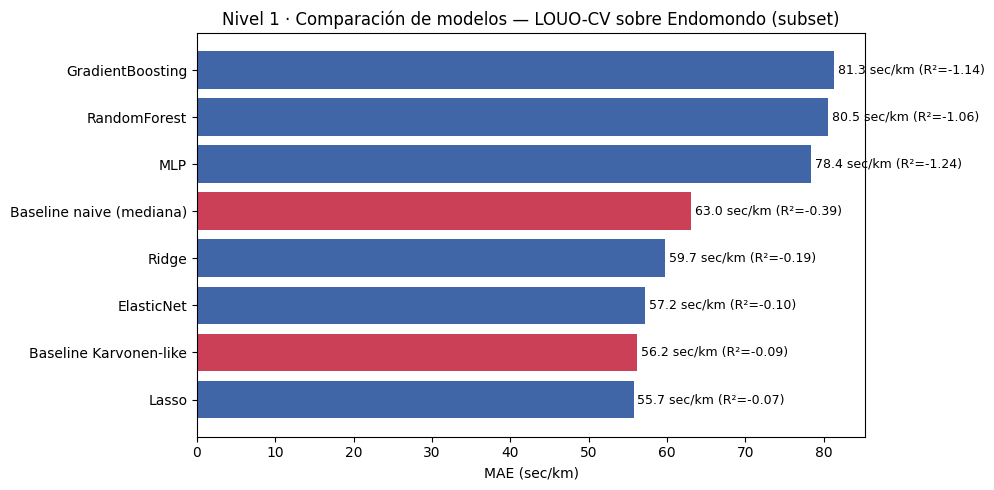

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_results.sort_values('MAE_sec_km', ascending=True)
colors = ['#C41E3A' if 'Baseline' in n else '#1F4B99' for n in df_plot['modelo']]
ax.barh(df_plot['modelo'], df_plot['MAE_sec_km'], color=colors, alpha=0.85)
ax.set_xlabel('MAE (sec/km)')
ax.set_title('Nivel 1 · Comparación de modelos — LOUO-CV sobre Endomondo (subset)')
for i, (v, r2) in enumerate(zip(df_plot['MAE_sec_km'], df_plot['R2'])):
    ax.text(v + 0.5, i, f'{v:.1f} sec/km (R²={r2:.2f})', va='center', fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / 'nb12_fig1_comparacion_modelos.png'); plt.show()

## 5 · Comparación estadística Friedman–Nemenyi

Según el protocolo de tesis, no basta con rankear por MAE global; hay que testear si las diferencias entre top modelos son significativas vía **Friedman** (global) + **Nemenyi** post-hoc.

In [9]:
from scipy.stats import friedmanchisquare

# MAE por usuario para cada modelo (top-5)
top5 = df_results[~df_results['modelo'].str.contains('Baseline')].head(5)['modelo'].tolist()
print('Top-5 modelos:', top5)

mae_per_user = {}
for name in top5:
    preds = preds_by_model[name]
    per_user = pd.DataFrame({'userId': g_sub, 'err': np.abs(y_sub - preds)}).groupby('userId')['err'].mean()
    mae_per_user[name] = per_user

mae_matrix = pd.DataFrame(mae_per_user)
print(f'MAE por usuario (shape: {mae_matrix.shape}):')
print(mae_matrix.describe().round(3))

# Friedman test
stat, p_value = friedmanchisquare(*[mae_matrix[c].values for c in mae_matrix.columns])
print(f'\nFriedman χ² = {stat:.3f}, p-value = {p_value:.4f}')
print(f'Conclusión: {"hay diferencias significativas" if p_value < 0.05 else "NO hay diferencias significativas"} entre modelos (α=0.05)')

Top-5 modelos: ['Lasso', 'ElasticNet', 'Ridge', 'MLP', 'RandomForest']
MAE por usuario (shape: (10, 5)):
        Lasso  ElasticNet   Ridge     MLP  RandomForest
count  10.000      10.000  10.000  10.000        10.000
mean    0.850       0.870   0.915   1.541         1.129
std     0.533       0.521   0.531   1.317         0.710
min     0.363       0.362   0.347   0.241         0.120
25%     0.495       0.521   0.525   0.773         0.620
50%     0.691       0.759   0.811   1.224         1.049
75%     0.908       0.937   1.102   1.862         1.616
max     2.036       2.005   2.038   4.860         2.485

Friedman χ² = 15.360, p-value = 0.0040
Conclusión: hay diferencias significativas entre modelos (α=0.05)


In [10]:
# Nemenyi post-hoc
try:
    import scikit_posthocs as sp
    nemenyi = sp.posthoc_nemenyi_friedman(mae_matrix.values)
    nemenyi.index = mae_matrix.columns; nemenyi.columns = mae_matrix.columns
    print('Matriz p-values Nemenyi:')
    print(nemenyi.round(3))
except ImportError:
    print('scikit_posthocs no instalado → pip install scikit-posthocs')

Matriz p-values Nemenyi:
              Lasso  ElasticNet  Ridge    MLP  RandomForest
Lasso         1.000       0.999  0.436  0.038         0.025
ElasticNet    0.999       1.000  0.618  0.081         0.056
Ridge         0.436       0.618  1.000  0.790         0.708
MLP           0.038       0.081  0.790  1.000         1.000
RandomForest  0.025       0.056  0.708  1.000         1.000


## 6 · Intervalos conformales sobre el mejor modelo

Split-conformal prediction: garantiza cobertura empírica (1−α) sin supuestos fuertes.

In [11]:
from sklearn.model_selection import GroupShuffleSplit

best_name = df_results.iloc[0]['modelo']
if 'Baseline' in best_name:
    best_name = [n for n in df_results['modelo'] if 'Baseline' not in n][0]
print('Mejor modelo según MAE:', best_name)
best_model = candidates[best_name]

alpha = 0.2  # cobertura nominal 80%

# Split por usuario: 60% train, 20% cal, 20% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=0)
idx_train, idx_rest = next(gss1.split(X_sub, y_sub, g_sub))
g_rest = g_sub[idx_rest]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=0)
idx_cal_rel, idx_test_rel = next(gss2.split(X_sub[idx_rest], y_sub[idx_rest], g_rest))
idx_cal = idx_rest[idx_cal_rel]; idx_test = idx_rest[idx_test_rel]

scaler = StandardScaler().fit(X_sub[idx_train])
mdl = best_model.__class__(**best_model.get_params()).fit(scaler.transform(X_sub[idx_train]), y_sub[idx_train])
p_cal  = mdl.predict(scaler.transform(X_sub[idx_cal]))
p_test = mdl.predict(scaler.transform(X_sub[idx_test]))
scores = np.abs(y_sub[idx_cal] - p_cal)
n_cal = len(scores)
k = int(np.ceil((n_cal + 1) * (1 - alpha)))
q = np.sort(scores)[min(k-1, n_cal-1)]
cov_emp = np.mean(np.abs(y_sub[idx_test] - p_test) <= q)
print(f'n_cal={n_cal}, cuantil q={q:.3f} min/km ({q*60:.1f} sec/km)')
print(f'Cobertura empírica: {cov_emp:.3f} (nominal {1-alpha:.2f})')
print(f'Ancho IC 80%: ±{q*60:.1f} sec/km')

Mejor modelo según MAE: Lasso
n_cal=77, cuantil q=0.784 min/km (47.0 sec/km)
Cobertura empírica: 0.729 (nominal 0.80)
Ancho IC 80%: ±47.0 sec/km


## 7 · Guardar artefacto del Nivel 1

In [12]:
# Reentrenar con TODO el subset para el artefacto final
scaler_final = StandardScaler().fit(X_sub)
final_model = best_model.__class__(**best_model.get_params()).fit(scaler_final.transform(X_sub), y_sub)

artefacto = {
    'model': final_model,
    'scaler': scaler_final,
    'features': FEATURES,
    'target': TARGET,
    'conformal_q_min_km': float(q),
    'alpha': alpha,
    'n_train_sessions': int(X_sub.shape[0]),
    'n_users': int(len(np.unique(g_sub))),
    'model_name': best_name,
    'metrics': df_results.to_dict('records'),
    'dataset_source': 'Endomondo FitRec (Ni et al. WWW 2019)',
    'version': '1.0',
    'date': '2026-04-23',
}
out_pkl = OUT_DIR / 'nivel1_prior_poblacional.pkl'
with open(out_pkl, 'wb') as f:
    pickle.dump(artefacto, f)
print(f'Artefacto guardado: {out_pkl}')
print(f'Usar en NB13 para inicializar Nivel 2 (transfer learning + fine-tuning con RUNA/Strava)')

Artefacto guardado: C:\Users\RentAdvisor\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb12\nivel1_prior_poblacional.pkl
Usar en NB13 para inicializar Nivel 2 (transfer learning + fine-tuning con RUNA/Strava)


---

## Interpretación para la tesis

**Si el mejor MAE del subset < MAE Karvonen**: hay evidencia de que ML supera el baseline clásico → Nivel 1 es útil.

**Si no**: documentar honestamente y considerar features adicionales (por ejemplo, descontar tendencia lineal FC-ritmo para aislar la residual).

**Escalar**: `12b_run_full.py` corre sobre TODO el dataset Endomondo limpio (~40K sesiones / ~800 usuarios) con naiveautoml timeout 1h.

**Siguiente notebook**: **NB13 — Nivel 2 generalizable RUNA/Strava** con transfer learning desde este artefacto.